#  **Machine Learning**

## **Importing libraries**

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [269]:
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi']=150
plt.rcParams['font.size']=12

## **Loading dataset**

In [270]:
df=sns.load_dataset('titanic')

## **Have a look on the five random rows of the data**

In [271]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
345,1,2,female,24.0,0,0,13.0000,S,Second,woman,False,F,Southampton,yes,True
321,0,3,male,27.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
131,0,3,male,20.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
557,0,1,male,NaN,0,0,227.5250,C,First,man,True,NaN,Cherbourg,no,True
315,1,3,female,26.0,0,0,7.8542,S,Third,woman,False,NaN,Southampton,yes,True


## **Shape of the data**

In [272]:
df.shape

(891, 15)

## **Name of the columns**

In [273]:
df.columns.to_list()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

## **Applying statics functions on the data** 

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [275]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## **Checking missing values**

In [276]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [277]:
df['deck'].isnull().sum()

688

## **Dropping deck column**

In [278]:
df.drop(columns=['deck'], inplace=True)

In [279]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [280]:
df.shape

(891, 14)

## **Filling missing values of the Age column**

In [281]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer()
df['age']=imputer.fit_transform(df[['age']]).ravel()

In [282]:
df['age'].isnull().sum()

0

## **Filling missing values in embarked column**

In [283]:
df['embarked'].isnull().sum()

2

In [284]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='most_frequent')
df['embarked']=imputer.fit_transform(df[['embarked']]).ravel()

In [285]:
df['embarked'].isnull().sum()

0

## **Heatmap to check the relation of survived column with others columns**

In [286]:
df_corr=df.select_dtypes(include=[np.number])

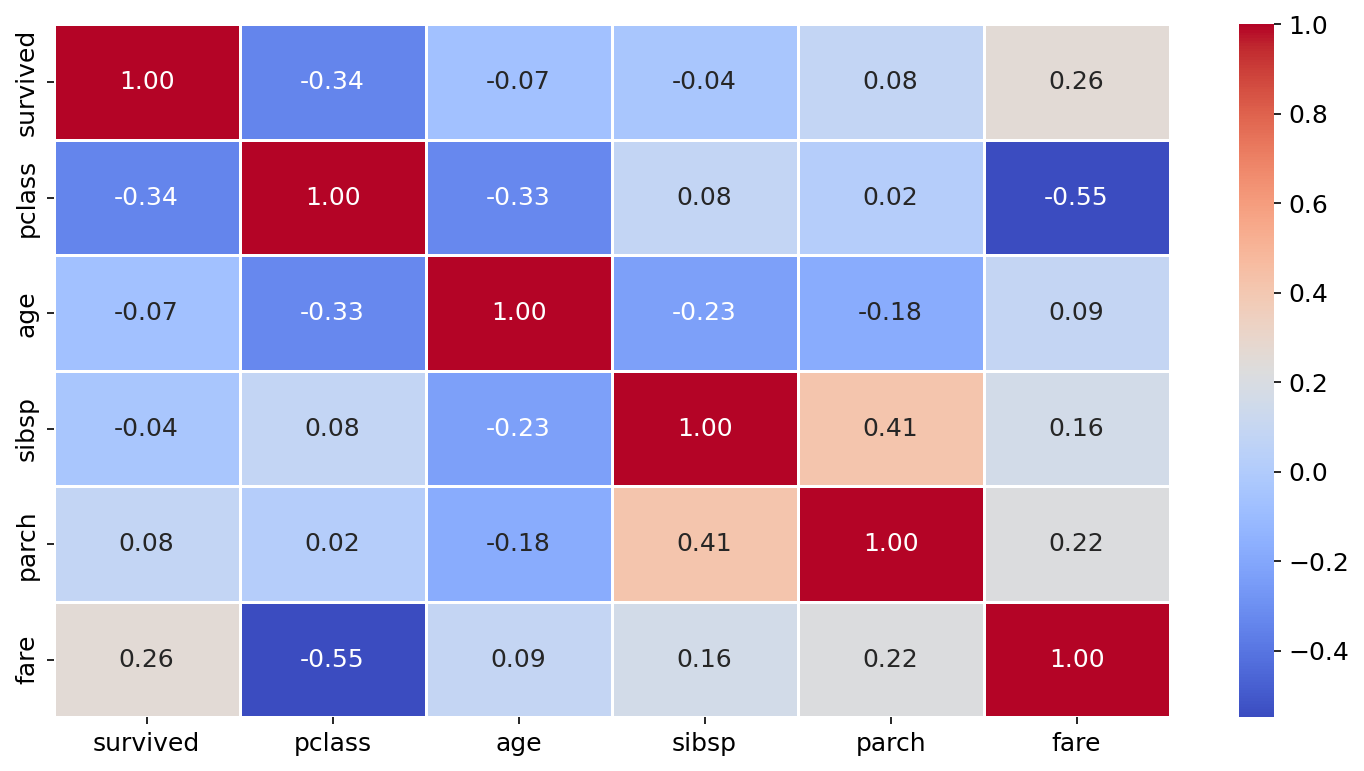

In [287]:
# Heatmap to check the relationship between the features and the target variable
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

In [288]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

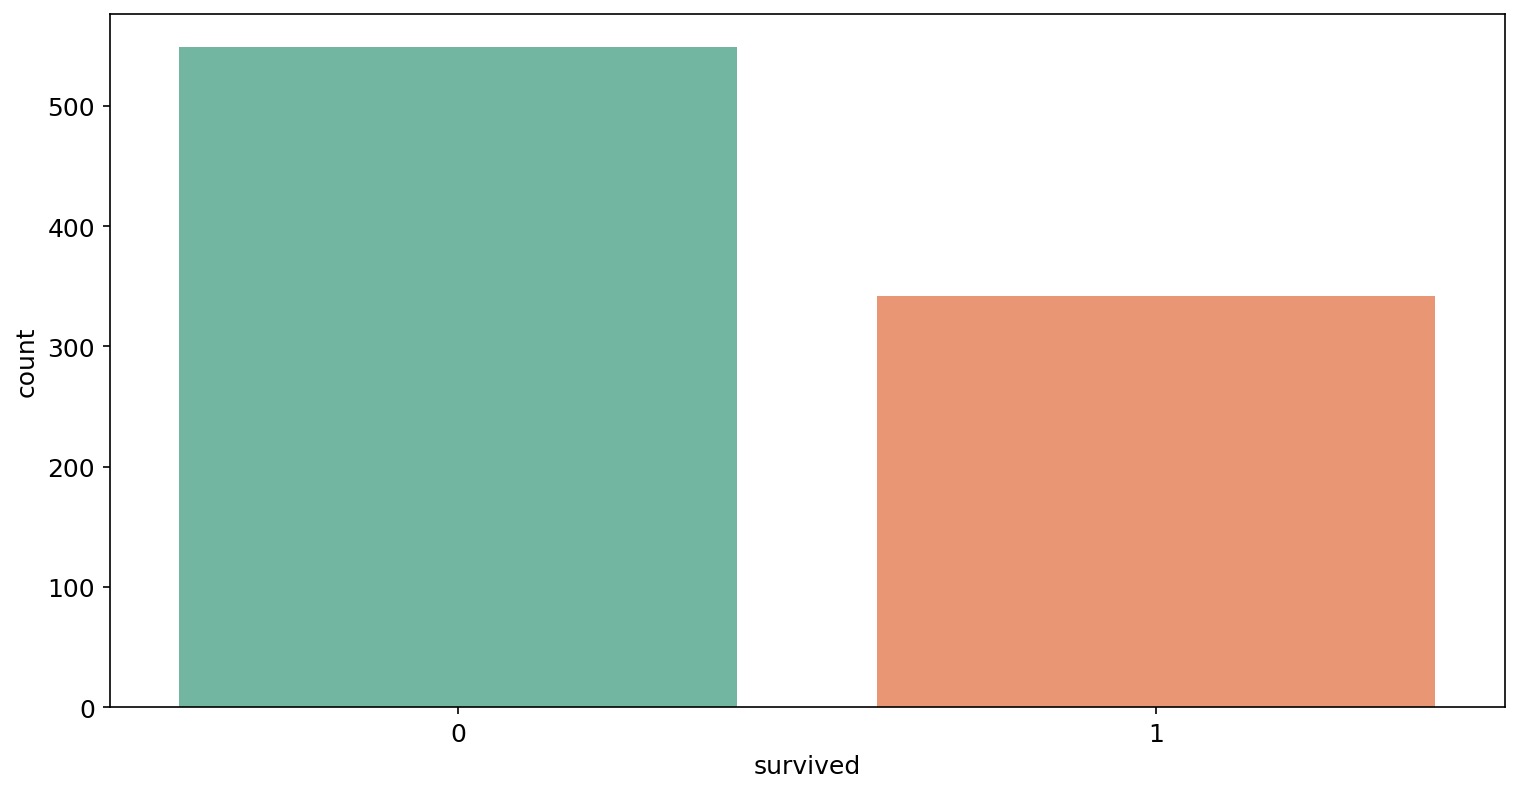

In [289]:
sns.countplot(x='survived', data=df,palette='Set2')
plt.show()

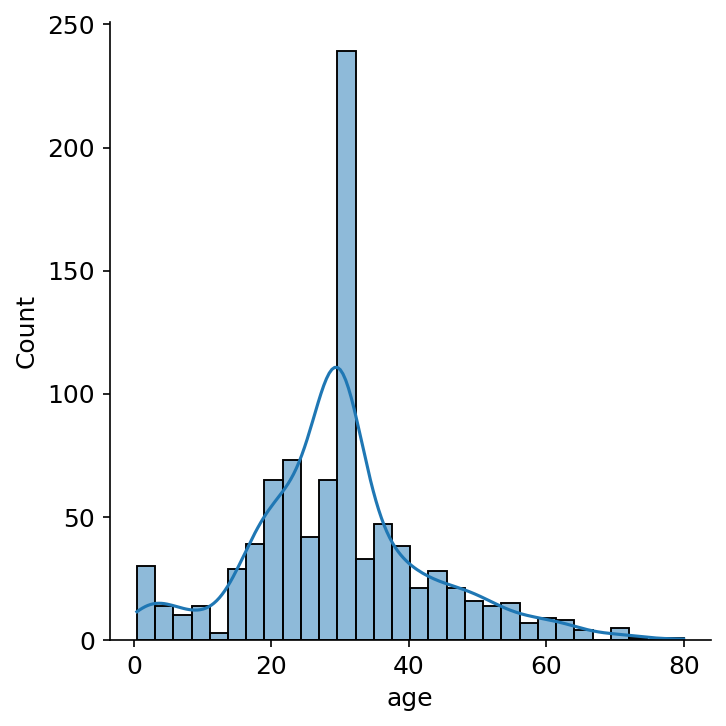

In [290]:
sns.displot(x='age',data=df,kde=True)
plt.show()

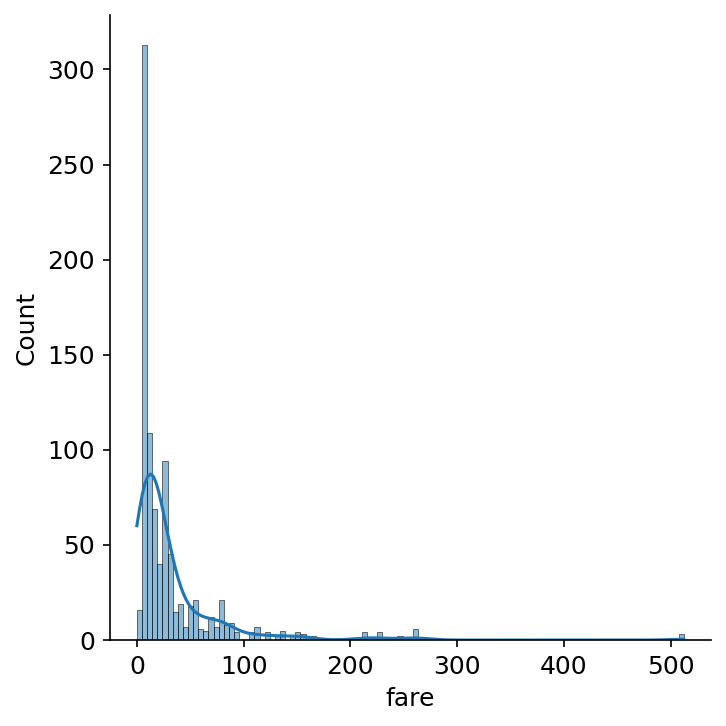

In [291]:
sns.displot(x='fare',data=df,kde=True)
plt.show()

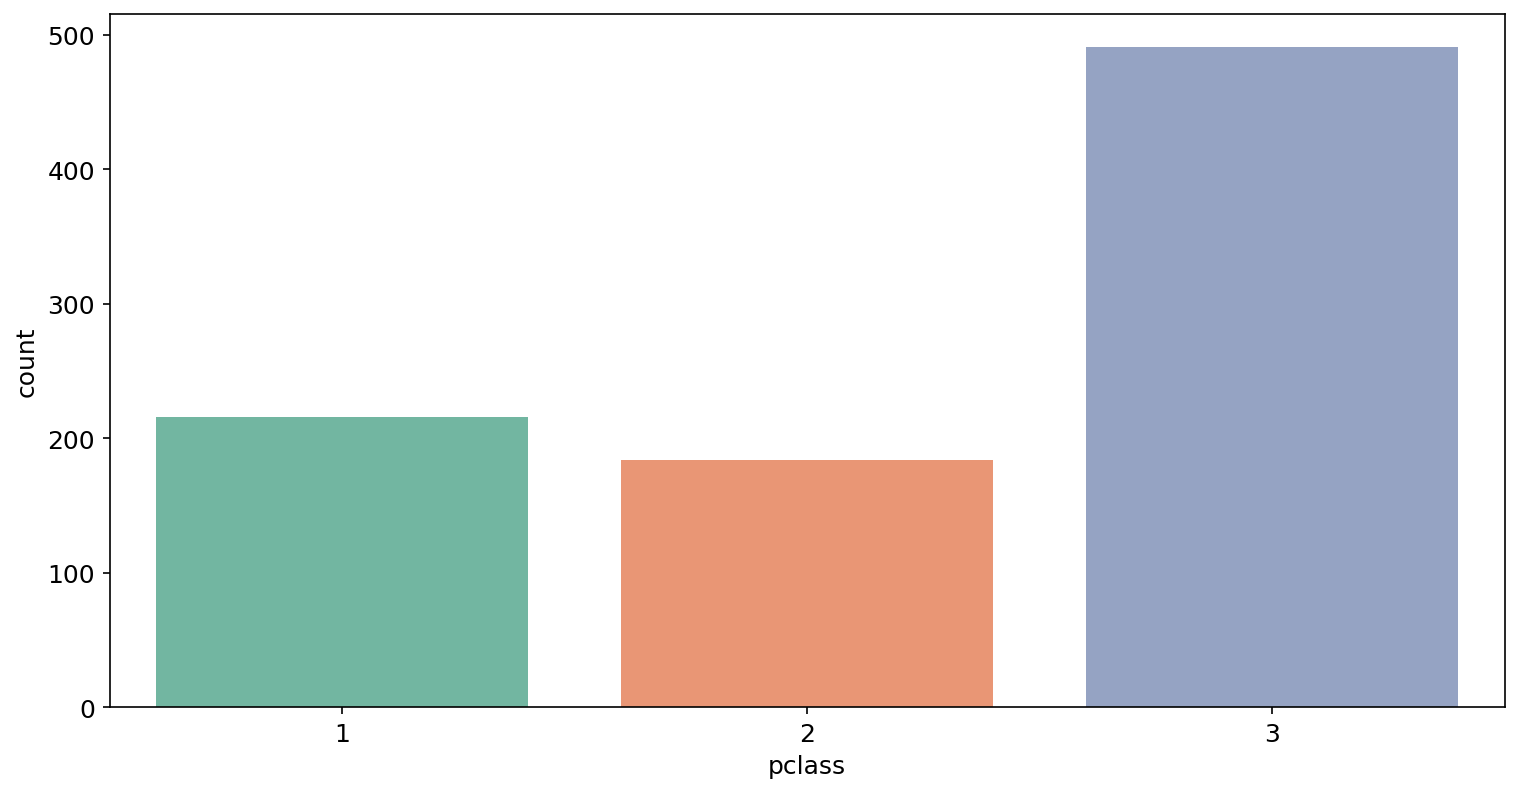

In [292]:
sns.countplot(x='pclass',data=df,palette='Set2')
plt.show()

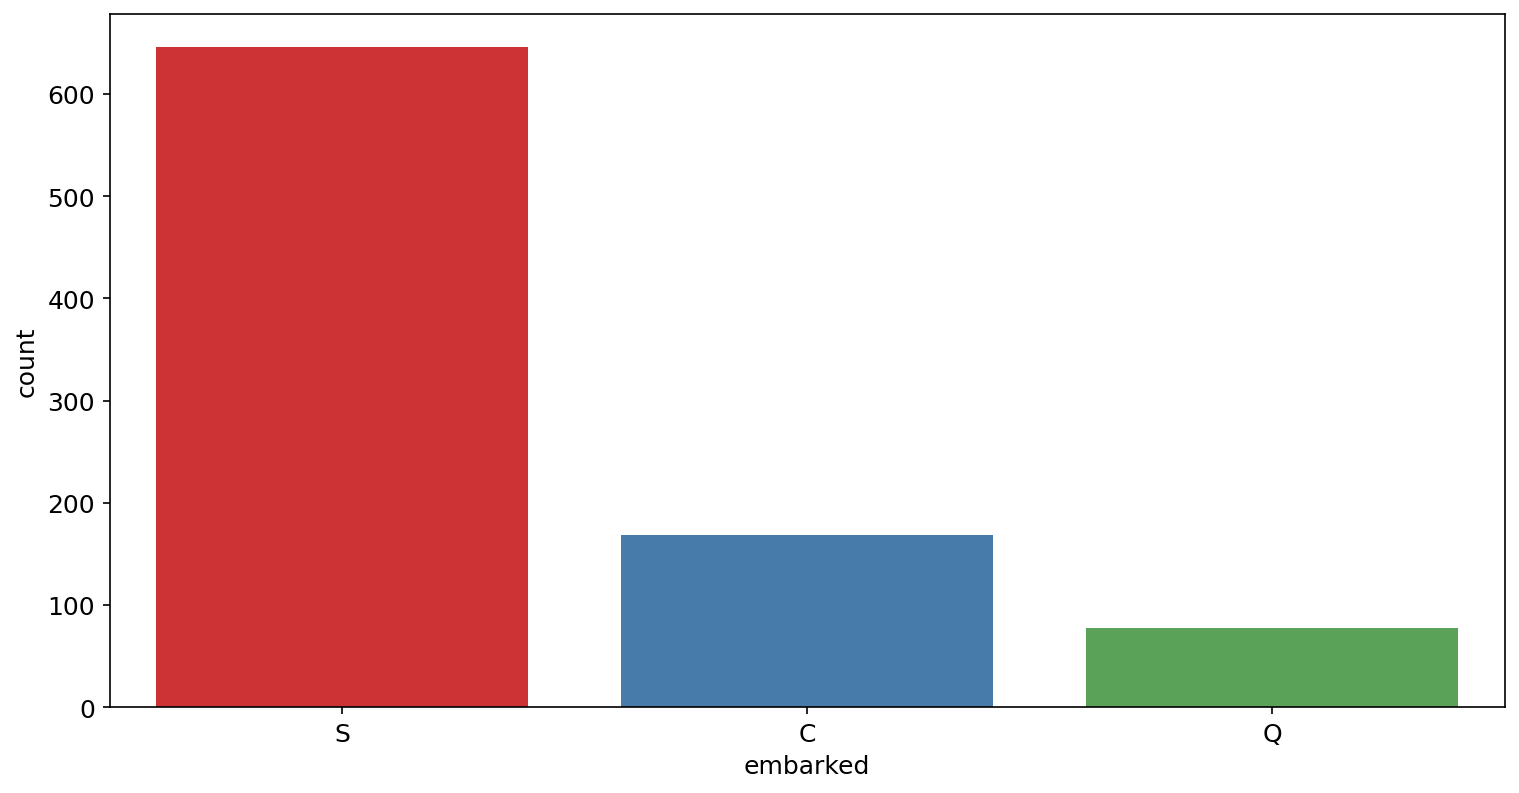

In [293]:
sns.countplot(x='embarked',data=df,palette='Set1')
plt.show()

In [294]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


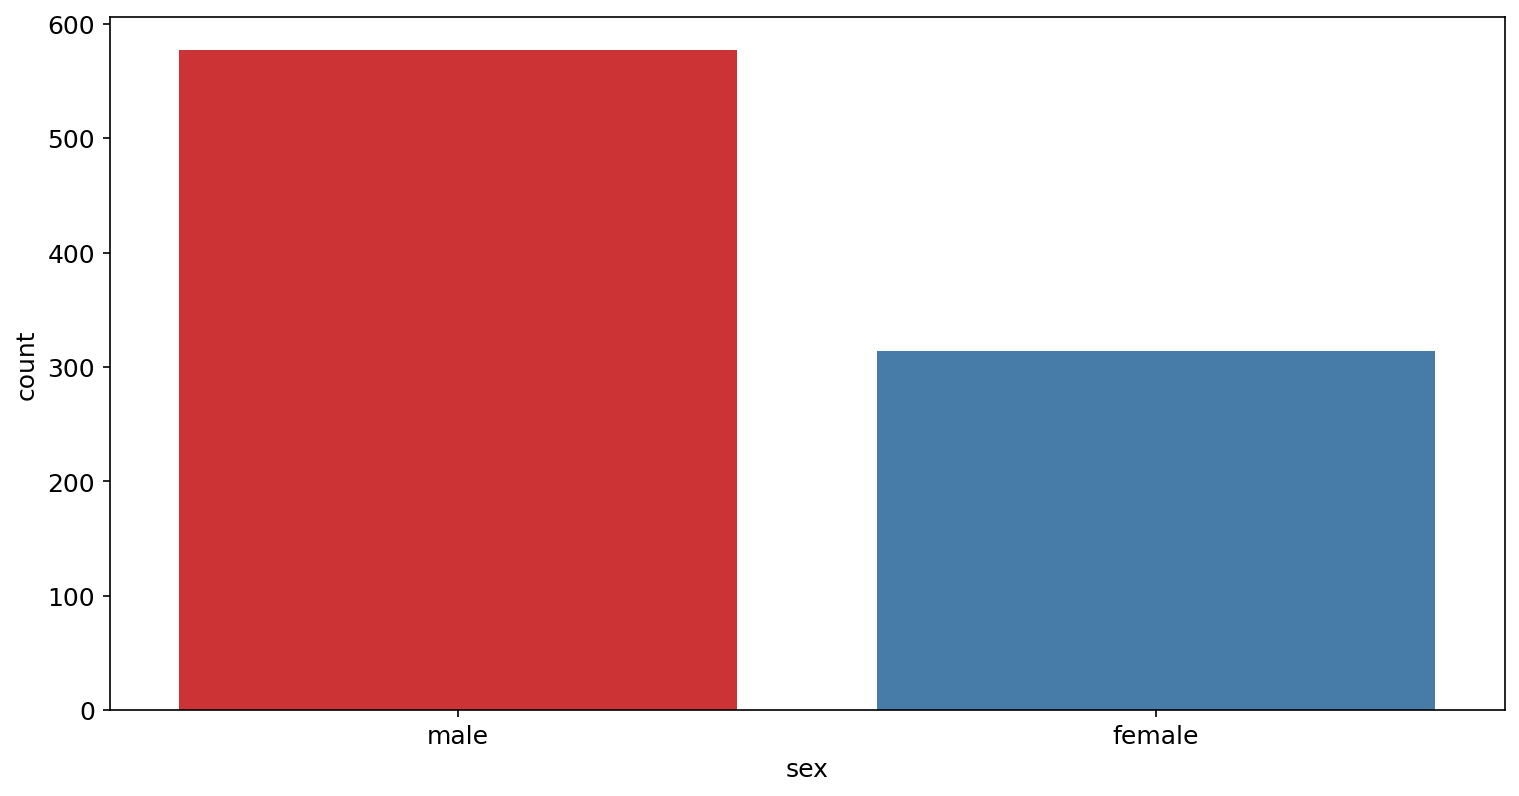

In [295]:
sns.countplot(x='sex', data=df,palette='Set1')
plt.show()

In [296]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [297]:
df['family_size']=df['sibsp']+df['parch']
df['family_size'].value_counts()

family_size
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64

In [298]:
df['family']=df['family_size'].apply(lambda x: 'Alone' if x==0 else ('Small' if x<=3 else 'Large'))

In [299]:
df['family'].value_counts()

family
Alone    537
Small    292
Large     62
Name: count, dtype: int64

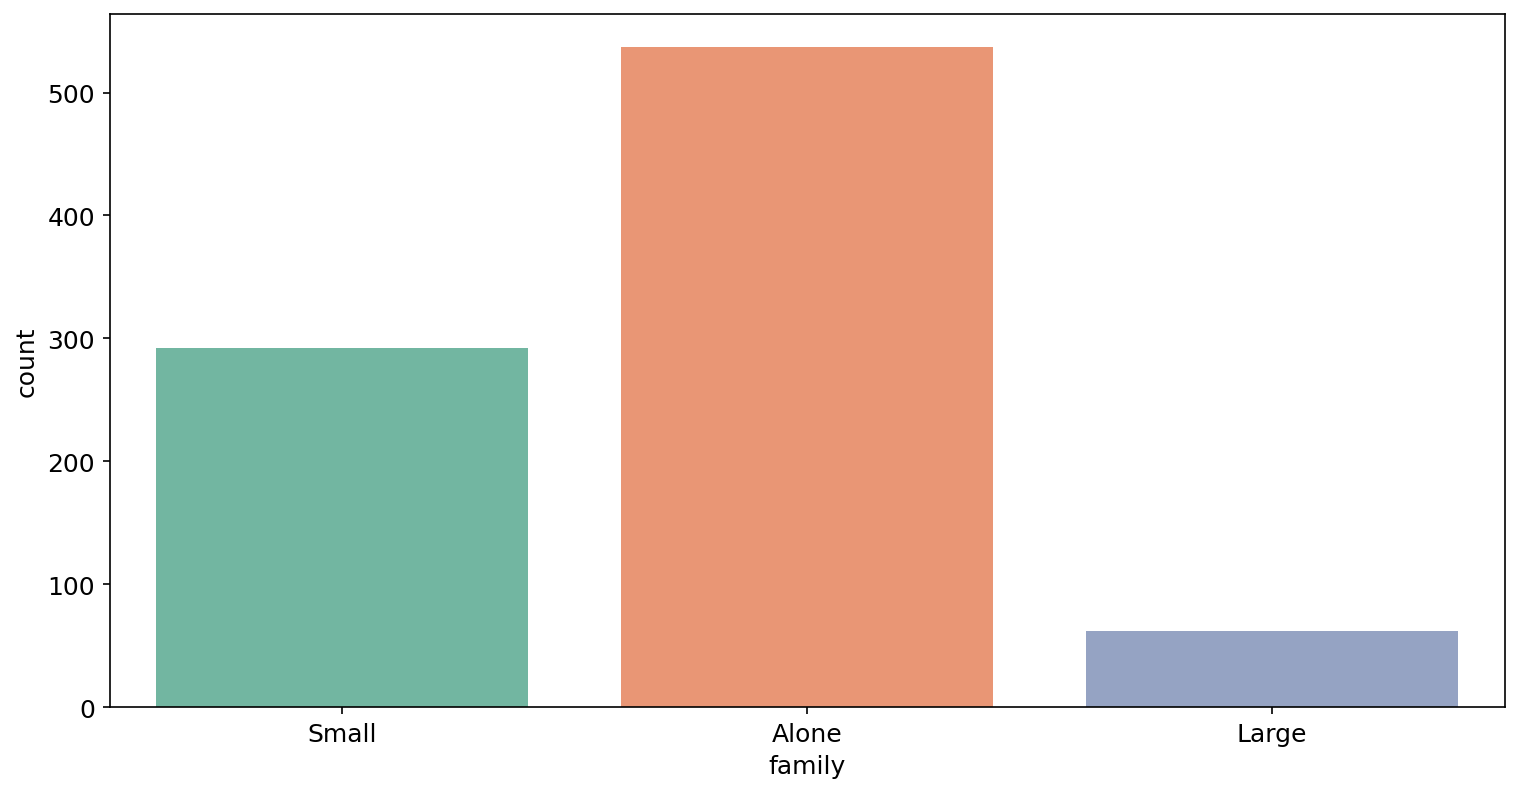

In [300]:
sns.countplot(x='family', data=df,palette='Set2')
plt.show()

In [301]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
features = df.drop(columns=['survived'])
numeric_features = features.select_dtypes(include=[np.number])


In [302]:
numeric_features.head()

,pclass,age,sibsp,parch,fare,family_size
0,3,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,3,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,3,35.0,0,0,8.0500,0


In [303]:
categorical_features = features.select_dtypes(include=[object])
categorical_features.head()


,sex,embarked,who,embark_town,alive,family
0,male,S,man,Southampton,no,Small
1,female,C,woman,Cherbourg,yes,Small
2,female,S,woman,Southampton,yes,Alone
3,female,S,woman,Southampton,yes,Small
4,male,S,man,Southampton,no,Alone


## **Droping alive who and embar_town columns**

In [304]:
categorical_features.drop(columns=['alive','embark_town'],axis=1, inplace=True)

In [305]:
categorical_features

,sex,embarked,who,family
0,male,S,man,Small
1,female,C,woman,Small
2,female,S,woman,Alone
3,female,S,woman,Small
4,male,S,man,Alone
...,...,...,...,...
886,male,S,man,Alone
887,female,S,woman,Alone
888,female,S,woman,Small
889,male,C,man,Alone


In [306]:
X=df.drop(columns=['survived'],axis=1)
Y=df['survived']

In [307]:
# Importing train test split and model selection libraries
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [308]:
from sklearn.compose import ColumnTransformer
preprocces = ColumnTransformer(
    transformers=(
        ('num', StandardScaler(), numeric_features.columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features.columns)
    )
)


In [336]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
pipeline= make_pipeline(
    
    preprocces,
    LogisticRegression()
)

In [337]:
from sklearn import set_config
set_config(display='diagram')
display(pipeline)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

## **Training model**

In [338]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [342]:
y_pred=pipeline.predict(X_test)

In [343]:
#Calculating the accuracy of the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8156424581005587
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179

Confusion Matrix:
[[91 14]
 [19 55]]


In [346]:
train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)

print("Train:", train_acc)
print("Test:", test_acc)

Train: 0.8286516853932584
Test: 0.8156424581005587


---
## As the train and test accuracy ia very close its mean it is best fit model

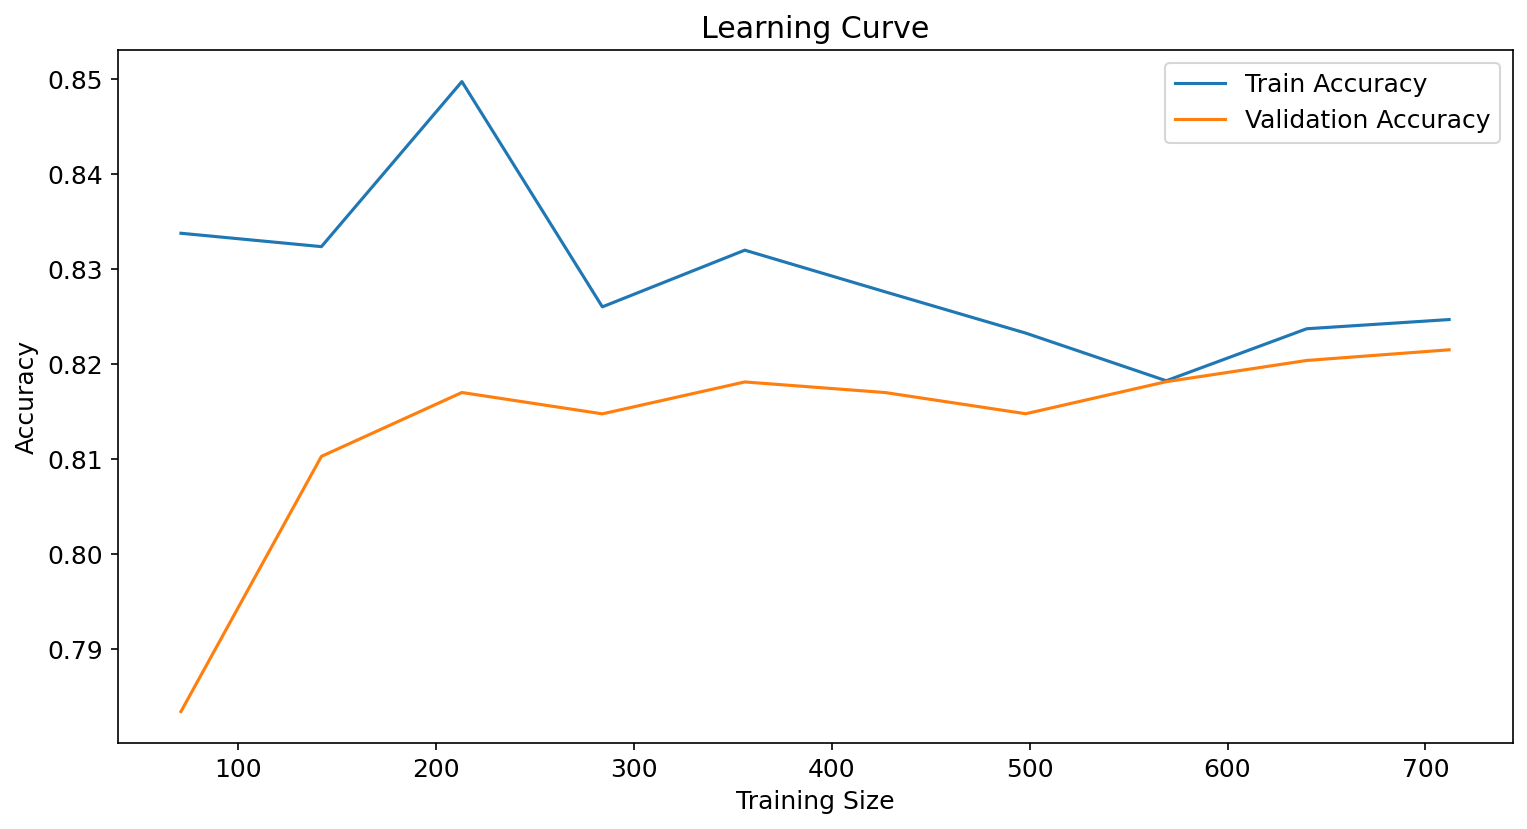

In [ ]:

train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X, Y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

# Mean scores
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Plot
plt.plot(train_sizes, train_mean, label='Train Accuracy')
plt.plot(train_sizes, val_mean, label='Validation Accuracy')

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()